<a href="https://colab.research.google.com/github/aligreo/TriEncoder-Unet-Project/blob/main/experiments/msseg_preprocessing_archeticture_experiment_4_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install SimpleITK monai gdown

Using Python 3.12.13 environment at: /usr
Resolved 23 packages in 325ms
Prepared 2 packages in 1.47s
Installed 2 packages in 10ms
 + monai==1.6.0
 + simpleitk==2.5.5


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
import os
import glob
import zipfile
import random
from pathlib import Path
import torch
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load MSSEG dataset

In [4]:
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=(), path_must_include=None):
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        full_path_upper = f.upper()
        if path_must_include and path_must_include.upper() not in full_path_upper:
            continue
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(nii_files, case_log_id="Unknown Case"):
    if not nii_files:
        print(f"  [Warning] No NIfTI files found at all for {case_log_id}")
        return None

    flair = first_match(nii_files, ["FLAIR"], path_must_include="PREPROCESSED_DATA")
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"], path_must_include="PREPROCESSED_DATA")

    t1_exclude = ["GADO", "GD", "GAD", "CONTRAST", "FLAIR", "T2", "CONSENSUS", "MASK", "SEG", "GT"]
    t1 = first_match(nii_files, ["T1"], t1_exclude, path_must_include="PREPROCESSED_DATA")

    if not t1:
        dp_fallback = first_match(nii_files, ["DP"], t1_exclude, path_must_include="PREPROCESSED_DATA")
        if dp_fallback:
            print(f"  [CRITICAL WARNING] T1 is missing for {case_log_id}, and DP scan was found. Skipping case to avoid Channel Corruption!")

    label = (first_match(nii_files, ["CONSENSUS"]) or first_match(nii_files, ["LESION"]) or first_match(nii_files, ["GT"]))

    if not (flair and t1 and t2 and label):
        missing = []
        if not flair: missing.append("FLAIR")
        if not t1: missing.append("T1")
        if not t2: missing.append("T2")
        if not label: missing.append("LABEL/CONSENSUS")
        print(f"  [Dropped Case] {case_log_id} is missing modalities: {missing}")
        return None

    return {"flair": flair, "t1": t1, "t2": t2, "label": label}

def collect_dataset(root_dir, source_name):
    root_dir = str(root_dir)
    if not os.path.exists(root_dir): return []
    patient_map = {}

    for root, dirs, files in os.walk(root_dir):
        nii_in_dir = [os.path.join(root, f) for f in files if f.lower().endswith(('.nii', '.nii.gz'))]
        if not nii_in_dir: continue

        parts = Path(root).parts
        patient_folder = next((p for p in parts if "PATIENT_" in p.upper()), None)

        if patient_folder:
            idx = parts.index(patient_folder)
            center_folder = parts[idx-1] if idx > 0 else "Center_Unknown"
            key = f"{center_folder}_{patient_folder}"
            if key not in patient_map: patient_map[key] = []
            patient_map[key].extend(nii_in_dir)

    final_cases = []
    for key, all_files in patient_map.items():
        case_log_id = f"{source_name}_{key}"
        item = find_case_files(all_files, case_log_id=case_log_id)
        if item:
            item["source"] = source_name
            item["case_id"] = case_log_id
            final_cases.append(item)

    return sorted(final_cases, key=lambda x: x['case_id'])

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)

msseg_train_files = collect_dataset(msseg_root, "MSSEG_TRAIN")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")

print(f"MSSEG train cases found: {len(msseg_train_files)}")
print(f"MSSEG test cases found: {len(msseg_test_files)}")

MSSEG train cases found: 15
MSSEG test cases found: 38


## Data Preprocessing & SplitSplit

In [5]:
from sklearn.model_selection import train_test_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd,
    RandCropByPosNegLabeld, EnsureTyped, CropForegroundd,
    RandFlipd, RandRotate90d, RandScaleIntensityd, RandShiftIntensityd,
    RandGaussianNoised, RandBiasFieldd, RandAdjustContrastd, Lambdad,
)
from monai.data import PersistentDataset, DataLoader
import os

def binarize_label(x):
    return (x > 0).astype(x.dtype)

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
    Spacingd(
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"),
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

num_samples_per_image = 6
train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(96, 96, 96), pos=5, neg=1,
        num_samples=num_samples_per_image, image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.2, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.15, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01),
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)),
    RandAdjustContrastd(keys="image", prob=0.2, gamma=(0.8, 1.2)),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])
test_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])

# Updated: Use all 15 cases for both Training and Validation
train_files = msseg_train_files
val_files = msseg_train_files
test_files = msseg_test_files

print(f"--- Dataset Statistics ---")
print(f"Initial volumes for Train/Val: {len(train_files)}")
print(f"Initial volumes for Test: {len(test_files)}")
print(f"Number of images before augmentation (train): {len(train_files)}")
print(f"Number of images after augmentation (train, {num_samples_per_image} crops per volume): {len(train_files) * num_samples_per_image}")

cache_dir_train = "/content/persistent_cache_train"
cache_dir_val = "/content/persistent_cache_val"
cache_dir_test = "/content/persistent_cache_test"

os.makedirs(cache_dir_train, exist_ok=True)
os.makedirs(cache_dir_val, exist_ok=True)
os.makedirs(cache_dir_test, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)
test_ds = PersistentDataset(data=test_files, transform=test_transforms, cache_dir=cache_dir_test)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

--- Dataset Statistics ---
Initial volumes for Train/Val: 15
Initial volumes for Test: 38
Number of images before augmentation (train): 15
Number of images after augmentation (train, 6 crops per volume): 90


## Data Analysis

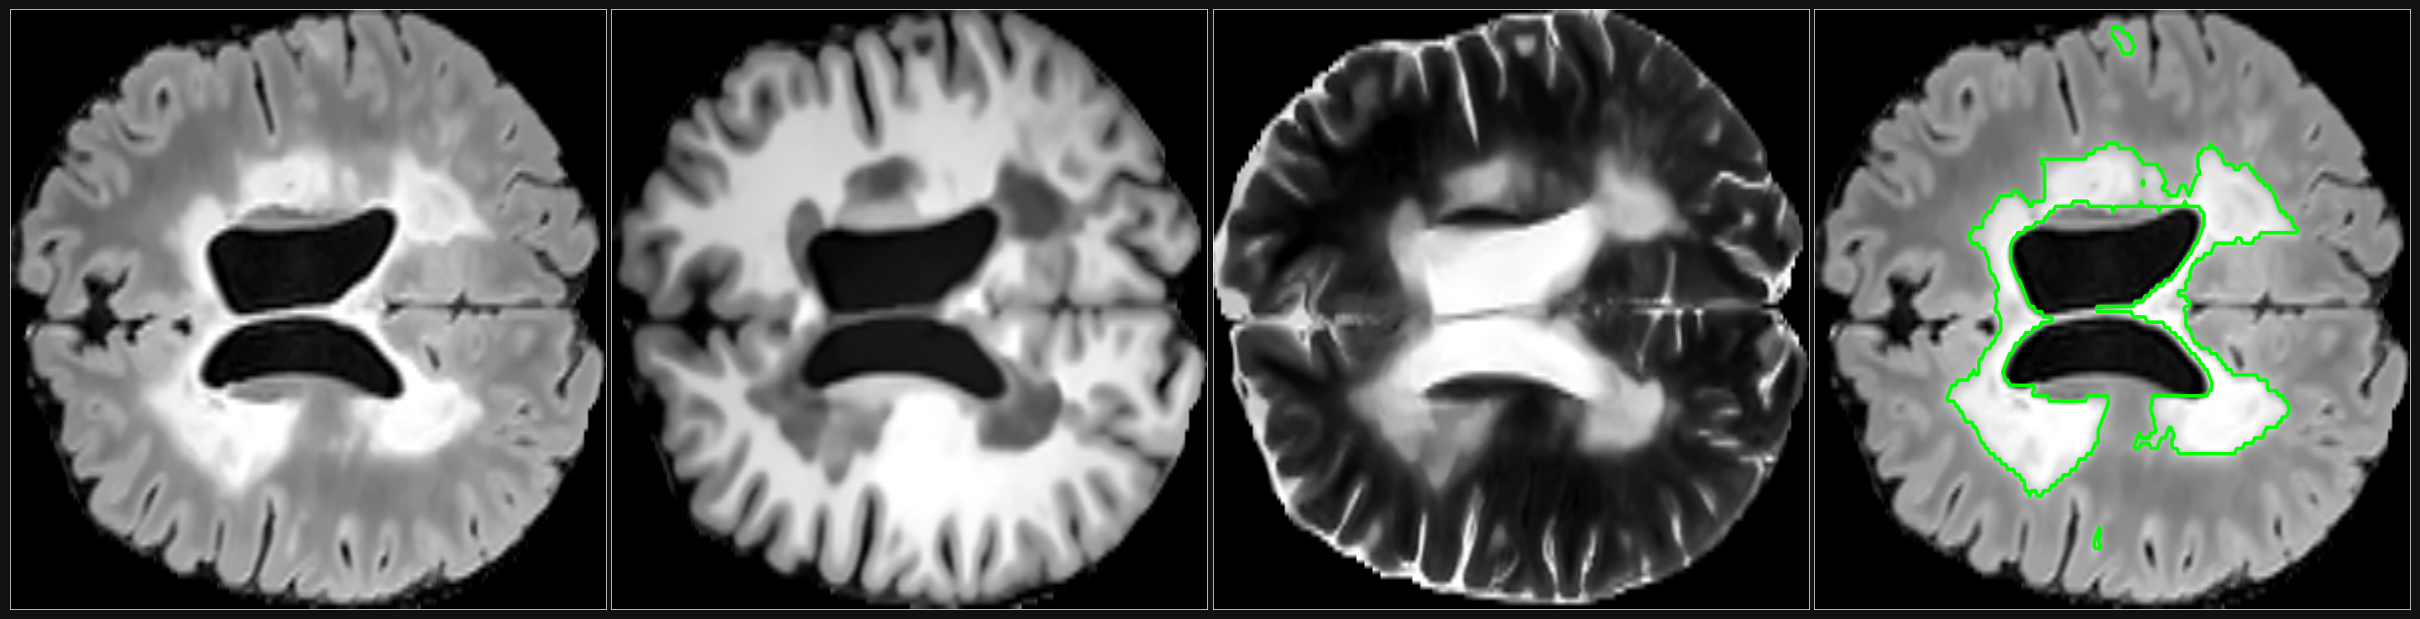

In [61]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def normalize_image(img):
    img = img.astype(np.float32)
    mask = img > 0
    if np.any(mask):
        low = np.percentile(img[mask], 2)
        high = np.percentile(img[mask], 98)
        img = np.clip(img, low, high)
        img = (img - low) / (high - low + 1e-8)
    return img

def crop_brain(img, margin=0):
    mask = img > 0
    if not np.any(mask): return img, (0, img.shape[0], 0, img.shape[1])
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0, x0 = max(y0 - margin, 0), max(x0 - margin, 0)
    y1, x1 = min(y1 + margin, img.shape[0]), min(x1 + margin, img.shape[1])
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

def visualize_sample(sample_dict, slice_idx=None):
    data = {k: nib.load(sample_dict[k]).get_fdata() for k in ["flair", "t1", "t2", "label"]}
    if slice_idx is None:
        lesion_area = data["label"].sum(axis=(0, 1))
        slice_idx = np.argmax(lesion_area) if lesion_area.max() > 0 else data["label"].shape[2] // 2

    slices = {k: data[k][:, :, slice_idx] for k in data}
    for k in ["flair", "t1", "t2"]: slices[k] = normalize_image(slices[k])
    _, bbox = crop_brain(slices["flair"])
    y0, y1, x0, x1 = bbox
    for k in slices: slices[k] = slices[k][y0:y1, x0:x1]

    # Initialize figure with a background color for the 'border' effect
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, facecolor='#111111')

    panels = [
        (slices["flair"], "gray", None),
        (slices["t1"], "gray", None),
        (slices["t2"], "gray", None),
        (slices["flair"], "gray", slices["label"])
    ]

    for i, (img, cmap, lbl) in enumerate(panels):
        ax = axes[i]
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='bilinear', origin='lower')

        if lbl is not None:
            ax.contour(lbl, levels=[0.5], colors='lime', linewidths=2.5, origin='lower')

        # Add a thin white border around each individual panel
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('white')
            spine.set_linewidth(0.5)

        ax.set_xticks([])
        ax.set_yticks([])

    # Use wspace to create a small gap (the border effect)
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0.01)
    plt.show()

if 'train_files' in globals() and train_files:
    visualize_sample(train_files[0])

## Model Architecture (Tri-Encoder with Deep Supervision)

In [11]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConvBlock3D(nn.Module):
    def __init__(self, input_channels, output_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class AttentionGate3D(nn.Module):
    def __init__(self, gating_channels, skip_channels, intermediate_channels):
        super().__init__()
        self.W_gating = nn.Sequential(
            nn.Conv3d(gating_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.W_skip = nn.Sequential(
            nn.Conv3d(skip_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.attention_filter = nn.Sequential(
            nn.Conv3d(intermediate_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, gating_signal, skip_connection):
        relevance_map = self.relu(self.W_gating(gating_signal) + self.W_skip(skip_connection))
        attention_coefficients = self.attention_filter(relevance_map)
        return skip_connection * attention_coefficients

class TriEncoderAttentionUNet3D(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        self.flair_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t1_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t2_l1 = ConvBlock3D(1, 16, dropout=0.0)

        self.flair_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t1_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t2_level_2 = ConvBlock3D(16, 32, dropout=dropout)

        self.fuse_l1 = ConvBlock3D(48, 32, dropout=dropout)
        self.fuse_level_2 = ConvBlock3D(96, 64, dropout=dropout)
        self.joint_l3 = ConvBlock3D(64, 128, dropout=dropout)

        self.bottleneck = ConvBlock3D(128, 256, dropout=dropout * 2)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate3D(128, 128, 64)
        self.dec3 = ConvBlock3D(256, 128, dropout=dropout)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate3D(64, 64, 32)
        self.dec2 = ConvBlock3D(128, 64, dropout=dropout)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionGate3D(32, 32, 16)
        self.dec1 = ConvBlock3D(64, 32, dropout=dropout)

        self.final = nn.Conv3d(32, 1, kernel_size=1)
        self.aux3 = nn.Conv3d(128, 1, kernel_size=1)
        self.aux2 = nn.Conv3d(64, 1, kernel_size=1)

    def forward(self, x, return_aux=True):
        flair_input = x[:, 0:1]
        t1_input = x[:, 1:2]
        t2_input = x[:, 2:3]

        f1 = self.flair_l1(flair_input)
        t1_1 = self.t1_l1(t1_input)
        t2_1 = self.t2_l1(t2_input)
        fused_skip_l1 = self.fuse_l1(torch.cat([f1, t1_1, t2_1], dim=1))

        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        fused_skip_l2 = self.fuse_level_2(torch.cat([f2, t1_2, t2_2], dim=1))

        fused_f3 = self.joint_l3(self.pool(fused_skip_l2))
        bottle = self.bottleneck(self.pool(fused_f3))

        up_l3 = self.up3(bottle)
        att3 = self.att3(up_l3, fused_f3)
        dec_l3 = self.dec3(torch.cat([up_l3, att3], dim=1))

        up_l2 = self.up2(dec_l3)
        att2 = self.att2(up_l2, fused_skip_l2)
        dec_l2 = self.dec2(torch.cat([up_l2, att2], dim=1))

        up_l1 = self.up1(dec_l2)
        att1 = self.att1(up_l1, fused_skip_l1)
        dec_l1 = self.dec1(torch.cat([up_l1, att1], dim=1))

        out_final = self.final(dec_l1)

        if return_aux:
            o3 = F.interpolate(self.aux3(dec_l3), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            o2 = F.interpolate(self.aux2(dec_l2), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            return out_final, o3, o2
        return out_final

model = TriEncoderAttentionUNet3D(dropout=0.15).to(device)

## Loss function

In [12]:
from monai.losses import DiceFocalLoss

class DeepSupervisedDiceFocalLoss(nn.Module):
    def __init__(self, lambda_dice=0.7, lambda_focal=0.3):
        super().__init__()
        self.base_loss = DiceFocalLoss(
            sigmoid=True, squared_pred=True,
            lambda_dice=lambda_dice, lambda_focal=lambda_focal
        )
        self.aux_weights = [1.0, 0.3, 0.15]

    def forward(self, logits_list, targets):
        loss = 0.0
        for i, logits in enumerate(logits_list):
            w = self.aux_weights[i]
            if logits.shape[2:] != targets.shape[2:]:
                logits = F.interpolate(logits, size=targets.shape[2:], mode="trilinear", align_corners=False)
            loss += w * self.base_loss(logits, targets)
        normalizer = sum(self.aux_weights[:len(logits_list)])
        return loss / normalizer

criterion = DeepSupervisedDiceFocalLoss(lambda_dice=0.7, lambda_focal=0.3)

## Training Loop

In [13]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

max_epochs = 20
roi_size = (96, 96, 96)
sw_batch_size = 2
accumulation_steps = 2
weight_path = "best_tri_encoder_msseg_only.pth"

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
steps_per_epoch = len(train_loader) // accumulation_steps
total_steps = steps_per_epoch * max_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4, total_steps=total_steps, pct_start=0.3)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)

history_train_loss = []
history_val_loss = []
history_val_dice = []
best_metric = -1

if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Loaded existing weights from {weight_path}; continuing training.")

def predict_fn(inputs):
    return sliding_window_inference(
        inputs=inputs, roi_size=roi_size, sw_batch_size=sw_batch_size,
        predictor=lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian",
    )

def run_validation():
    model.eval()
    dice_metric.reset()
    val_loss_total = 0.0
    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                val_logits = predict_fn(val_inputs)
                val_loss_total += criterion((val_logits,), val_labels).item()
            val_probs = torch.sigmoid(val_logits)
            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)
    avg_dice = dice_metric.aggregate().item()
    avg_val_loss = val_loss_total / max(len(val_loader), 1)
    dice_metric.reset()
    return avg_val_loss, avg_dice

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    for step, batch_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)):
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits_final, logits_aux3, logits_aux2 = model(inputs, return_aux=True)
            loss = criterion((logits_final, logits_aux3, logits_aux2), labels)
        scaler.scale(loss).backward()
        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=12.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
        epoch_loss += loss.item()

    epoch_loss /= max(step + 1, 1)
    history_train_loss.append(epoch_loss)
    avg_val_loss, avg_val_dice = run_validation()
    history_val_loss.append(avg_val_loss)
    history_val_dice.append(avg_val_dice)

    current_lr = optimizer.param_groups[0]["lr"]
    if (epoch + 1) % 10 == 0 or epoch == 0 or (epoch + 1) == max_epochs:
        print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {avg_val_loss:.4f}  Val Dice: {avg_val_dice:.4f}  LR: {current_lr:.2e}")

    if avg_val_dice > best_metric:
        best_metric = avg_val_dice
        torch.save(model.state_dict(), weight_path)
        print(f"  *** New Best Val Dice ({best_metric:.4f}) at epoch {epoch+1} - Model Saved ***")

print(f"Training complete. Best Val Dice: {best_metric:.4f}")

Loaded existing weights from best_tri_encoder_msseg_only.pth; continuing training.


Epoch 1/20:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [1/20]  Train Loss: 0.2464  Val Loss: 0.3555  Val Dice: 0.7703  LR: 1.07e-05
  *** New Best Val Dice (0.7703) at epoch 1 - Model Saved ***


Epoch 2/20:   0%|          | 0/15 [00:00<?, ?it/s]

  *** New Best Val Dice (0.7767) at epoch 2 - Model Saved ***


...

Epoch 17/20:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 18/20:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [20/20]  Train Loss: 0.2065  Val Loss: 0.3142  Val Dice: 0.8145  LR: 2.61e-08
Training complete. Best Val Dice: 0.8215


## Final Test Evaluation

In [15]:
weight_path = "/content/best_tri_encoder_msseg_only.pth"
model.load_state_dict(torch.load(weight_path, map_location=device))

<All keys matched successfully>

In [16]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2
# accumulation_steps = 2

model.load_state_dict(torch.load(weight_path, map_location=device))
model.eval()
test_dice_metric = DiceMetric(include_background=False, reduction="mean")
case_scores = []

with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Testing on MSSEG_TEST"):
        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            test_logits = sliding_window_inference(
                test_inputs, roi_size, sw_batch_size,
                lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian"
            )
        test_probs = torch.sigmoid(test_logits)
        test_outputs_discrete = [post_pred(i) for i in test_probs]

        case_metric = DiceMetric(include_background=False, reduction="mean")
        case_metric(y_pred=test_outputs_discrete, y=test_labels)
        case_dice = case_metric.aggregate().item()
        case_scores.append(case_dice)

        test_dice_metric(y_pred=test_outputs_discrete, y=test_labels)
        cid = test_data.get("case_id", ["unknown"])[0]
        if isinstance(cid, (list, tuple)):
            cid = cid[0]

avg_test_dice = test_dice_metric.aggregate().item()

print(f"FINAL TEST DICE (MSSEG_TEST, 38 cases): {avg_test_dice:.4f}")

Testing on MSSEG_TEST:   0%|          | 0/38 [00:00<?, ?it/s]

FINAL TEST DICE (MSSEG_TEST, 38 cases): 0.6688


## Test results table

In [17]:
import pandas as pd
import numpy as np
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import torch
from tqdm.auto import tqdm

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2

dice_metric = DiceMetric(include_background=False, reduction="none")
conf_matrix = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="none")

model.eval()
results = []

print("Evaluating 38 test cases...")
with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader)):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        # Inference
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(inputs, roi_size, sw_batch_size, lambda x: model(x, return_aux=False))

        probs = torch.sigmoid(logits)
        preds = post_pred(probs)

        # Calculate Volumes
        gt_vol = torch.sum(labels).item()
        pred_vol = torch.sum(preds).item()

        # Calculate Metrics
        dice_metric(y_pred=preds, y=labels)
        conf_matrix(y_pred=preds, y=labels)

        dice_val = dice_metric.aggregate().item()

        # Handle Empty Ground Truth cases (NaN handling)
        if gt_vol == 0:
            if pred_vol == 0:
                dice_val = 1.0  # Perfect prediction of empty case
            else:
                dice_val = 0.0  # False positive on empty case
        elif np.isnan(dice_val):
            dice_val = 0.0

        prec_rec = conf_matrix.aggregate()
        precision_val = prec_rec[0].item() if not torch.isnan(prec_rec[0]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)
        recall_val = prec_rec[1].item() if not torch.isnan(prec_rec[1]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)

        results.append({
            "Patient ID": case_id,
            "Dice": round(float(dice_val), 4),
            "Precision": round(float(precision_val), 4),
            "Recall (Sens)": round(float(recall_val), 4),
            "Ground Truth Volume (mm3)": gt_vol,
            "Pred Volume (mm3)": pred_vol
        })

        # Reset metrics for next case
        dice_metric.reset()
        conf_matrix.reset()

# Create DataFrame
df_results = pd.DataFrame(results)
# Highlight summary
print(f"Average Dice (including empty cases as 1.0): {df_results['Dice'].mean():.4f}")
display(df_results)

Evaluating 38 test cases...


  0%|          | 0/38 [00:00<?, ?it/s]

Average Dice (including empty cases as 1.0): 0.6722


,Patient ID,Dice,Precision,Recall (Sens),Ground Truth Volume (mm3),Pred Volume (mm3)
0,MSSEG_TEST_Center_01_Patient_01,0.4710,0.4070,0.5590,356.0,489.0
1,MSSEG_TEST_Center_01_Patient_02,0.8258,0.8405,0.8116,24458.0,23616.0
2,MSSEG_TEST_Center_01_Patient_03,0.8131,0.8361,0.7913,10981.0,10392.0
3,MSSEG_TEST_Center_01_Patient_04,0.8555,0.8341,0.8779,34830.0,36659.0
4,MSSEG_TEST_Center_01_Patient_05,0.8136,0.8579,0.7737,15743.0,14197.0
5,MSSEG_TEST_Center_01_Patient_06,0.6803,0.8348,0.5740,30266.0,20812.0
6,MSSEG_TEST_Center_01_Patient_07,0.6664,0.7368,0.6083,4598.0,3796.0
7,MSSEG_TEST_Center_01_Patient_08,0.7628,0.8930,0.6658,21421.0,15971.0
8,MSSEG_TEST_Center_01_Patient_09,0.5695,0.4871,0.6854,604.0,850.0
9,MSSEG_TEST_Center_01_Patient_10,0.7442,0.8152,0.6847,5166.0,4339.0


## centers statistics

In [24]:
import pandas as pd

# 1. Extract Center information from the Patient IDs in the results
def extract_center(patient_id):
    parts = patient_id.split('_')
    if 'Center' in parts:
        idx = parts.index('Center')
        return f"Center_{parts[idx+1]}"
    return "Unknown"

df_results['Center'] = df_results['Patient ID'].apply(extract_center)

# 2. Analyze distribution
test_centers = df_results['Center'].unique()
val_centers = set([extract_center(f['case_id']) for f in val_files])
train_centers = set([extract_center(f['case_id']) for f in train_files])

print(f"Centers in Training: {sorted(list(train_centers))}")
print(f"Centers in Validation: {sorted(list(val_centers))}")
print(f"Centers in Test: {sorted(list(test_centers))}")

# 3. Aggregate results by Center
# Fixed: Changed 'GT Volume (mm3)' to 'Ground Truth Volume (mm3)' to match df_results
center_summary = df_results.groupby('Center').agg({
    'Dice': ['mean', 'std', 'count'],
    'Precision': 'mean',
    'Recall (Sens)': 'mean',
    'Ground Truth Volume (mm3)': 'mean'
}).round(4)

print("\nPerformance Summary per Center/Scanner:")
display(center_summary)

Centers in Training: ['Center_01', 'Center_07', 'Center_08']
Centers in Validation: ['Center_01', 'Center_07', 'Center_08']
Centers in Test: ['Center_01', 'Center_03', 'Center_07', 'Center_08']

Performance Summary per Center/Scanner:


Dice               Precision Recall (Sens)  \
             mean     std count      mean          mean   
Center                                                    
Center_01  0.7202  0.1241    10    0.7543        0.7032   
Center_03  0.6122  0.1936     8    0.5869        0.7479   
Center_07  0.7090  0.1602    10    0.6354        0.8374   
Center_08  0.6353  0.2434    10    0.6248        0.7827   

          Ground Truth Volume (mm3)  
                               mean  
Center                               
Center_01                 14842.300  
Center_03                 17462.125  
Center_07                  6241.100  
Center_08                 12039.700

## Zero dice case

## Training Curves

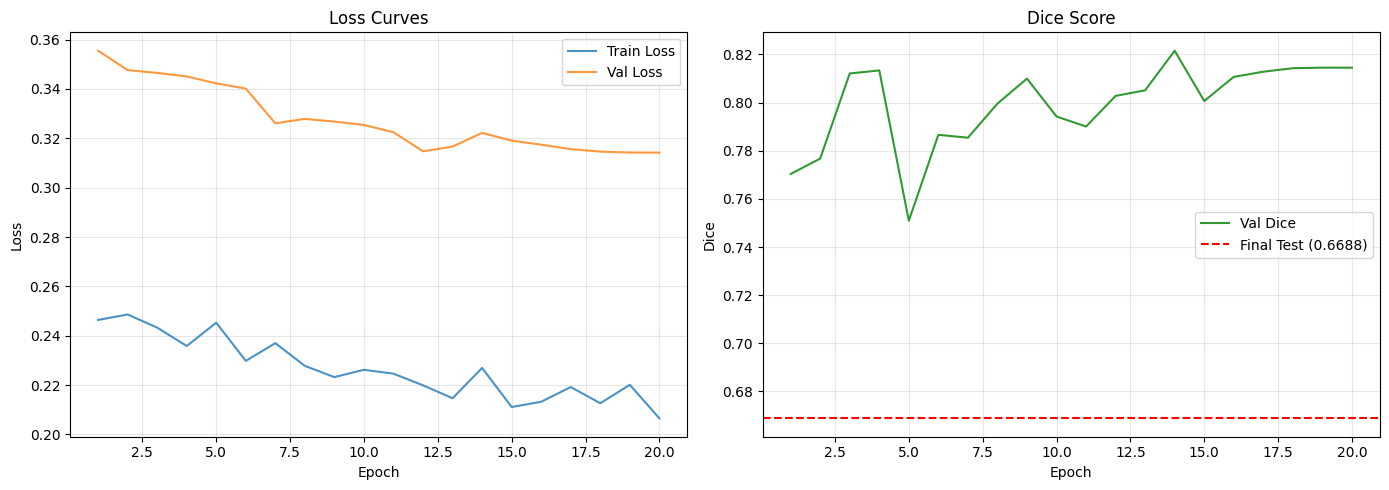

In [21]:
epochs_range = range(1, len(history_train_loss) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history_train_loss, label="Train Loss", alpha=0.8)
axes[0].plot(epochs_range, history_val_loss, label="Val Loss", alpha=0.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_val_dice, label="Val Dice", color="green", alpha=0.8)
axes[1].axhline(y=avg_test_dice, color="red", linestyle="--", label=f"Final Test ({avg_test_dice:.4f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_title("Dice Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test-Time Augmentation (TTA)

In [22]:
def predict_tta(inputs, model, roi_size, sw_batch_size):
    model.eval()
    with torch.no_grad():
        # 1. Original prediction
        pred = sliding_window_inference(inputs, roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian")

        # 2. Flip Axial
        pred += torch.flip(sliding_window_inference(torch.flip(inputs, [2]), roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5), [2])

        # 3. Flip Sagittal
        pred += torch.flip(sliding_window_inference(torch.flip(inputs, [3]), roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5), [3])

        # 4. Flip Coronal
        pred += torch.flip(sliding_window_inference(torch.flip(inputs, [4]), roi_size, sw_batch_size, lambda x: model(x, return_aux=False), overlap=0.5), [4])

    return pred / 4.0

### Final Test Evaluation with TTA

In [31]:
test_dice_metric_tta = DiceMetric(include_background=False, reduction="none")
case_scores_tta = []

with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Testing with TTA"):
        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            test_logits = predict_tta(test_inputs, model, roi_size, sw_batch_size)

        test_probs = torch.sigmoid(test_logits)
        test_outputs_discrete = [post_pred(i) for i in test_probs]

        # Calculate volumes to check for empty cases
        gt_vol = torch.sum(test_labels).item()
        pred_vol = torch.sum(test_outputs_discrete[0]).item()

        case_metric = DiceMetric(include_background=False, reduction="mean")
        case_metric(y_pred=test_outputs_discrete, y=test_labels)
        dice_val = case_metric.aggregate().item()

        # Custom logic: if both GT and Pred are empty, score is 1.0
        if gt_vol == 0:
            if pred_vol == 0:
                dice_val = 1.0
            else:
                dice_val = 0.0
        elif np.isnan(dice_val):
            dice_val = 0.0

        case_scores_tta.append(dice_val)

avg_test_dice_tta = np.mean(case_scores_tta)

print(f"FINAL TEST DICE WITH TTA : {avg_test_dice_tta:.4f}")
print(f"Best single-case Dice: {max(case_scores_tta):.4f}")
print(f"Worst single-case Dice: {min(case_scores_tta):.4f}")

Testing with TTA:   0%|          | 0/38 [00:00<?, ?it/s]

FINAL TEST DICE WITH TTA : 0.6867
Best single-case Dice: 1.0000
Worst single-case Dice: 0.1676


### TTA Comprehensive Metrics Table
We will now generate a full results table using TTA, including Dice, Precision, Recall, and Hausdorff Distance.

In [29]:
from monai.metrics import DiceMetric, ConfusionMatrixMetric, HausdorffDistanceMetric
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import torch

# Initialize metrics - using CPU for spatial metrics to avoid CuPy/thrust compilation errors
dice_metric = DiceMetric(include_background=False, reduction="none")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall", "accuracy"], reduction="none")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="none")

results_tta = []
model.eval()

print("Calculating TTA metrics (including Accuracy) for all 38 test cases...")
with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader)):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = predict_tta(inputs, model, roi_size, sw_batch_size)

        probs = torch.sigmoid(logits)
        preds = post_pred(probs)

        # Move to CPU for metric calculation
        preds_cpu = preds.cpu()
        labels_cpu = labels.cpu()

        dice_metric(y_pred=preds_cpu, y=labels_cpu)
        conf_metric(y_pred=preds_cpu, y=labels_cpu)
        hd95_metric(y_pred=preds_cpu, y=labels_cpu)

        d_val = dice_metric.aggregate().item()
        cm_vals = conf_metric.aggregate()
        hd_val = hd95_metric.aggregate().item()

        gt_vol = torch.sum(labels_cpu).item()
        pred_vol = torch.sum(preds_cpu).item()

        if gt_vol == 0 and pred_vol == 0:
            d_val, prec, rec, acc, hd_val = 1.0, 1.0, 1.0, 1.0, 0.0
        else:
            prec = cm_vals[0].item() if not torch.isnan(cm_vals[0]) else 0.0
            rec = cm_vals[1].item() if not torch.isnan(cm_vals[1]) else 0.0
            acc = cm_vals[2].item() if not torch.isnan(cm_vals[2]) else 0.0
            if np.isinf(hd_val) or np.isnan(hd_val): hd_val = 100.0

        results_tta.append({
            "Dice_TTA": float(d_val),
            "Accuracy_TTA": float(acc),
            "Precision_TTA": float(prec),
            "Recall_TTA": float(rec),
            "HD95_TTA": float(hd_val)
        })

        dice_metric.reset()
        conf_metric.reset()
        hd95_metric.reset()

df_tta_results = pd.DataFrame(results_tta)

print("\n--- TTA Global Averages (38 Test Cases) ---")
display(df_tta_results.mean().to_frame(name="Average").round(4))

Calculating TTA metrics (including Accuracy) for all 38 test cases...


  0%|          | 0/38 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:342: UserWarning: the ground truth of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:347: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(



--- TTA Global Averages (38 Test Cases) ---


,Average
Dice_TTA,0.6867
Accuracy_TTA,0.9982
Precision_TTA,0.6685
Recall_TTA,0.7794
HD95_TTA,17.8221
